# Feature-importance report — end to end, one schema in, one folder out

**Set the parameters, Run All, get a folder.** This is the operational notebook of
the package: it reads a `unified_schema_*`, joins the pools, ranks every feature,
optionally computes the bar and the holdout, and writes a **self-describing report
directory** — tables as CSV, figures as PNG, and a `metadata.json` recording
everything needed to reproduce the run and to know what it may be compared against.

The three study notebooks answer *what did we learn*. This one answers *run it and
give me the artefacts*.

| notebook | for |
|---|---|
| [feature_selection.ipynb](feature_selection.ipynb) | the un-windowed baseline, `d=1` |
| [windowed_selection.ipynb](windowed_selection.ipynb) | the sequence-model setup, `d=20` |
| [evaluation_study.ipynb](evaluation_study.ipynb) | whether either result is real (it is not — CONTEXT §6b-6d) |
| [cross_sectional_selection.ipynb](cross_sectional_selection.ipynb) | the cross-section, which is (CONTEXT §9) |
| **this one** | **produce and archive a run** |

## ⚠️ Read before quoting anything this writes

**A ranking without a null is descriptive, not evidence.** `RUN_NULL = False` makes
this notebook finish in a minute and produces a `metadata.json` whose `null` field
is `null` and a `README.md` that says so in bold. That is deliberate: CONTEXT §6b
found a positive out-of-sample IC on **shuffled labels**, so `IC > 0` is not a
result. Set `RUN_NULL = True` before the numbers leave your machine.

**A bar belongs to one configuration.** `zscore` moved its own bar 43 % without
touching the data (§6c). Changing the target, the representation, the lookback or
the universe invalidates the previous null — which is why `compare_reports()` puts
those columns beside the IC, so incomparability is visible before the number is.

## Imports

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
from IPython.display import Image, Markdown, display

from feature_selection import evaluation, plots, report, windows
from feature_selection.selector import FeatureSelector
from feature_selection.unified_reader import UnifiedSchemaReader

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plots.use_theme()

## Parameters — the whole run is configured here

Everything below this cell is mechanical. ⚠️ Each knob that changes an ANSWER is
recorded into `metadata.json`, so a report is never a bare table of feature names.

In [2]:
TICKER = "VCB"                    # the schema is unified_schema_<ticker>
POOLS = ["pool__basic", "pool__targets"]
TARGET = "return_5day"
OTHER_TARGETS = ["return_10day", "return_rel_5day", "return_rel_10day"]

LOOKBACK = 20                     # d — window length in sessions; 1 = un-windowed
HORIZON = 5                       # h — must match the target's own horizon
NORMALIZE = "none"                # "none" | "zscore" | "window_relative"
MAX_FEATURES = 12                 # cap on kept CHANNELS, after the redundancy prune
CORR_THRESHOLD = 0.9
N_SPLITS, MIN_TRAIN = 5, 500
DEVICE = "cpu"                    # ⚠️ part of the setup — see CONTEXT §5
RANDOM_STATE = 42

RUN_STABILITY = True              # per-fold SHAP ranking (cheap)
RUN_NULL = False                  # ⚠️ the BAR. Slow. See the warning above.
N_NULL = 20
RUN_HOLDOUT = False               # score an untouched tail once, with a control
HOLDOUT_START = "2024-06-01"

TOP_N_FIGURES = 30
NOTES = ""                        # free text, lands in metadata.json and README.md

# ⚠️ Identity and taxonomy columns are never candidates. On a single-ticker panel
# they are constant and would be dropped anyway; naming them keeps that a decision
# rather than an accident, and keeps this cell correct for a multi-ticker panel.
IDENTITY = [
    "exchange", "ticker", "sector", "sector_code", "industry_group",
    "industry_group_code", "industry", "industry_code",
    "sub_industry", "sub_industry_code",
]

## 1. Read and join

`UnifiedSchemaReader` types every column from `information_schema` rather than
guessing — psycopg2 returns `numeric` as `Decimal`, which pandas stores as dtype
`object`, so `close_adjust` would otherwise arrive looking like a string column.

⚠️ **`join_log` records which keys each merge actually used** and goes into the
report. Every pool is keyed `(date, exchange, ticker)` as of 2026-08-04, but the
join intersects per pair rather than assuming, so a pool that predates the change
joins correctly instead of silently wrongly.

In [3]:
reader = UnifiedSchemaReader(TICKER).connect()
overview = reader.overview()
panel = reader.join(POOLS)
join_log = reader.join_log
schema_name, database = reader.schema, reader.database
reader.close()

print(f"{schema_name}: {panel.shape[0]:,} rows x {panel.shape[1]} columns "
      f"({panel['date'].min():%Y-%m-%d} -> {panel['date'].max():%Y-%m-%d})")
overview

unified_schema_vcb: 4,235 rows x 42 columns (2009-06-30 -> 2026-06-25)


,table,rows,columns,key_columns,first_date,last_date
0,pool__basic,4235,38,"date, exchange, ticker",2009-06-30,2026-06-25
1,pool__targets,4235,7,"date, exchange, ticker",2009-06-30,2026-06-25


In [4]:
pd.DataFrame(join_log)

,table,join_keys,how,rows_before,rows_after,columns_added,duplicate_columns_dropped
0,pool__targets,"date, exchange, ticker",inner,4235,4235,4,


### The target's own arithmetic

In [5]:
labels = pd.DataFrame([{
    "target": column,
    "labelled": int(panel[column].notna().sum()),
    "unlabelled_tail": int(panel[column].isna().sum()),
    "mean": round(float(panel[column].mean()), 6),
    "sd": round(float(panel[column].std()), 6),
} for column in [TARGET] + [c for c in OTHER_TARGETS if c in panel.columns]])
labels

,target,labelled,unlabelled_tail,mean,sd
0,return_5day,4230,5,0.003190,0.042946
1,return_10day,4225,10,0.006458,0.059825
2,return_rel_5day,4228,7,0.001052,0.032045
3,return_rel_10day,4223,12,0.002170,0.043826


## 2. Run the selection

Six rankers → rank-average ensemble → correlation prune at channel level → purged
walk-forward. ⚠️ The purge gap is `d + h - 1`, not `h` (CONTEXT §1a).

In [6]:
selector = FeatureSelector(
    panel=panel,
    target=TARGET,
    exclude=IDENTITY + [c for c in OTHER_TARGETS if c != TARGET],
    max_features=MAX_FEATURES,
    corr_threshold=CORR_THRESHOLD,
    horizon=HORIZON,
    lookback=LOOKBACK,
    window_stats=windows.WINDOW_STATS,
    normalize=NORMALIZE,
    n_splits=N_SPLITS,
    min_train=MIN_TRAIN,
    device=DEVICE,
    random_state=RANDOM_STATE,
    holdout_start=HOLDOUT_START if RUN_HOLDOUT else None,
)

result = selector.run(stability=RUN_STABILITY)
result.setup.to_frame().T

,target,horizon_h,lookback_d,normalize,purge_gap_rows,window_stats,dropped_by_normalize,dev_samples,holdout_start,holdout_rows,purged_at_boundary,channels,design_columns,kept,device
setup,return_5day,5,20,none,24,"last, mean, slope, sd, min, max",1,4211,—,0,0,27,161,12,cpu


### The ranking — this is the deliverable

In [7]:
result.ranking.round(3)

,ensemble,kept,dropped_for,spearman,mutual_info,xgb_gain,xgb_shap,lasso,permutation
volume_negotiated,8.667,True,,0.233,0.000,0.453,0.596,0.0,1.000
foreign_own,8.667,True,,0.216,0.403,0.465,0.497,0.0,0.061
close_adjust,9.167,True,,0.055,1.000,0.645,1.000,0.0,0.000
open,9.333,True,,0.076,0.516,0.286,0.283,0.0,0.398
buy_order_vol,9.500,True,,0.022,0.323,0.701,0.468,0.0,0.313
close_raw,10.000,False,open,0.082,0.563,0.241,0.787,0.0,0.014
foreign_room_left,10.000,True,,0.159,0.443,0.470,0.274,0.0,0.087
low,10.000,False,open,0.076,0.555,0.840,0.311,0.0,0.012
high,10.167,False,open,0.075,0.486,0.277,0.346,0.0,0.146
n_sell_orders,10.333,True,,0.064,0.377,0.760,0.342,0.0,0.067


In [8]:
print("kept:", result.kept)
print("\ndropped as redundant:")
display(pd.Series(result.dropped_correlated, name="duplicated").to_frame())
if result.dead_methods:
    print(f"\n⚠️ dead methods (separated nothing): {result.dead_methods}")

kept: ['volume_negotiated', 'foreign_own', 'close_adjust', 'open', 'buy_order_vol', 'foreign_room_left', 'n_sell_orders', 'value_negotiated', 'foreign_sell_value', 'avg_vol_per_buy_order', 'foreign_net_volume', 'prop_buy_vol']

dropped as redundant:


,duplicated
close_raw,open
low,open
high,open
sell_order_vol,buy_order_vol
value_matched,n_sell_orders
n_buy_orders,n_sell_orders
volume_matched,buy_order_vol


### Walk-forward — the only numbers carrying a generalisation claim

In [9]:
display(result.validation.round(4))
evaluation.ic_summary(result.validation, HORIZON).to_frame().T.round(4)

,fold,feature_set,n_channels,n_columns,n_train,n_test,n_eff_test,ic,r2,hit_rate
0,fold 1,all channels,27,161,500,737,147.4,0.1130,-0.8549,0.5210
1,fold 1,selected,12,71,500,737,147.4,0.0486,-1.0644,0.5102
2,fold 2,all channels,27,161,1237,737,147.4,0.0667,-1.9163,0.4790
3,fold 2,selected,12,71,1237,737,147.4,0.0732,-2.0835,0.4803
4,fold 3,all channels,27,161,1974,737,147.4,0.0796,-1.6659,0.4315
5,fold 3,selected,12,71,1974,737,147.4,0.1169,-1.4468,0.4233
6,fold 4,all channels,27,161,2711,737,147.4,-0.0147,-0.4481,0.5020
7,fold 4,selected,12,71,2711,737,147.4,0.0574,-0.4590,0.5088
8,fold 5,all channels,27,161,3448,739,147.8,-0.0313,-0.3928,0.4614
9,fold 5,selected,12,71,3448,739,147.8,0.0218,-0.7821,0.5372


,folds,ic_mean,ic_trend_per_fold,ic_min,ic_max,ic_fold_sd,hit_rate,n_test_rows,n_eff_per_fold,se_ic_per_fold
selected,5.0,0.0636,-0.007,0.0218,0.1169,0.0352,0.492,737.0,147.4,0.0826


## 3. The bar, and the holdout

⚠️ Both are optional and both are OFF by default, because both are slow — and both
are what turn a ranking into evidence. A report written without them says so.

In [10]:
null = None
if RUN_NULL:
    def factory(frame):
        clone = FeatureSelector(
            panel=frame, target=TARGET,
            exclude=IDENTITY + [c for c in OTHER_TARGETS if c != TARGET],
            max_features=MAX_FEATURES, corr_threshold=CORR_THRESHOLD,
            horizon=HORIZON, lookback=LOOKBACK, normalize=NORMALIZE,
            n_splits=N_SPLITS, min_train=MIN_TRAIN, device=DEVICE,
            random_state=RANDOM_STATE,
        )
        return clone.run(stability=False)

    observed = evaluation.ic_summary(result.validation, HORIZON)["ic_mean"]
    null = evaluation.null_distribution(
        panel=panel, target=TARGET, factory=factory, observed=observed,
        horizon=HORIZON, lookback=LOOKBACK, n_draws=N_NULL, seed=7,
        label=f"{schema_name} / {TARGET}",
    )
    display(null.summary().to_frame().T)
else:
    print("⚠️ RUN_NULL is False — this report will record that no bar was computed.")

⚠️ RUN_NULL is False — this report will record that no bar was computed.


In [11]:
holdout = selector.score_holdout(result) if RUN_HOLDOUT else None
if holdout is not None:
    display(holdout.round(4))

## 4. Write the report

One folder: `metadata.json`, `README.md`, the CSVs and `figures/*.png`.

In [12]:
written = report.write_report(
    result,
    selector=selector,
    panel=panel,
    schema=schema_name,
    tables=POOLS,
    database=database,
    join_log=join_log,
    null=null,
    holdout=holdout,
    notes=NOTES,
    top=TOP_N_FIGURES,
)
written.summary().to_frame().T

,run_id,schema,tables,target,rows,channels,kept,ic_mean,ic_trend,hit_rate,null_bar,clears_null,files,path
report,2026-08-04__unified_schema_vcb__return_5day__2...,unified_schema_vcb,"pool__basic, pool__targets",return_5day,4235,27,12,0.063595,-0.006951,0.491974,None,None,18,D:\GIT\master-thesis\reports\feature_selection...


In [13]:
print(written.path)
for artefact in written.metadata["artifacts"]:
    print(f"  {artefact['bytes']:>9,}  {artefact['file']}")

D:\GIT\master-thesis\reports\feature_selection\2026-08-04__unified_schema_vcb__return_5day__205945
      5,245  feature_importance.csv
     18,144  design_scores.csv
      1,078  validation.csv
      1,036  target_correlation.csv
     14,736  channel_correlation.csv
      1,100  stability.csv
        822  coverage.csv
    126,339  figures/01_ensemble_ranking.png
    238,804  figures/02_method_heatmap.png
    115,449  figures/03_target_correlation.png
    220,205  figures/04_channel_correlation.png
    169,764  figures/05_stat_profile.png
     47,433  figures/06_validation.png
    146,323  figures/07_stability.png
     78,406  figures/08_coverage.png
     40,891  figures/09_target_distribution.png


### The README the run wrote about itself

In [14]:
display(Markdown(open(os.path.join(written.path, "README.md"), encoding="utf-8").read()))

# Feature-importance run — `return_5day`

*Generated 2026-08-04T13:59:47.127732+00:00 at commit `7ab2488+dirty`.*

## Input

- **schema** `unified_schema_vcb` (database `database_main_v2`)
- **tables** `pool__basic`, `pool__targets`
- **panel** 4,235 rows x 42 columns
- **range** 2009-06-30 to 2026-06-25 (4235 sessions, 1 tickers)

## Target

- **`return_5day`** — forward 5-session return on close_adjust
- horizon **5** sessions; 4,230 labelled, 5 unlabelled
- mean +0.00319, sd 0.04295, range -0.1876 to +0.2914

## Setup

| knob | value |
|---|---|
| `selector_class` | FeatureSelector |
| `lookback_d` | 20 |
| `horizon_h` | 5 |
| `normalize` | none |
| `purge_gap_rows` | 24 |
| `window_stats` | last, mean, slope, sd, min, max |
| `n_splits` | 5 |
| `min_train` | 500 |
| `max_features` | 12 |
| `corr_threshold` | 0.9 |
| `device` | cpu |
| `random_state` | 42 |
| `permutation_repeats` | 10 |
| `holdout_start` | — |
| `dev_samples` | 4211 |
| `design_columns` | 161 |

## Result

- **12 of 27 channels kept** after the |rho| >= 0.9 redundancy prune
- **top 10 by ensemble rank**: `volume_negotiated`, `foreign_own`, `close_adjust`, `open`, `buy_order_vol`, `close_raw`, `foreign_room_left`, `low`, `high`, `n_sell_orders`

| metric | selected | all channels |
|---|---|---|
| `ic_mean` | +0.0636 | +0.0427 |
| `ic_trend_per_fold` | -0.0070 | -0.0370 |
| `hit_rate` | +0.4920 | +0.4790 |
| `n_eff_per_fold` | 147.4 | 147.4 |

## The bar

- ⚠️ **NO NULL WAS COMPUTED FOR THIS RUN.** A positive IC is not a result on its own — see `CONTEXT.md` §6b and §8. Treat the ranking below as descriptive until a shuffled-label null has been run for *this* configuration.

## Files

- `feature_importance.csv`
- `design_scores.csv`
- `validation.csv`
- `target_correlation.csv`
- `channel_correlation.csv`
- `stability.csv`
- `coverage.csv`
- `figures/01_ensemble_ranking.png`
- `figures/02_method_heatmap.png`
- `figures/03_target_correlation.png`
- `figures/04_channel_correlation.png`
- `figures/05_stat_profile.png`
- `figures/06_validation.png`
- `figures/07_stability.png`
- `figures/08_coverage.png`
- `figures/09_target_distribution.png`
- `metadata.json`


### The figures

01_ensemble_ranking.png


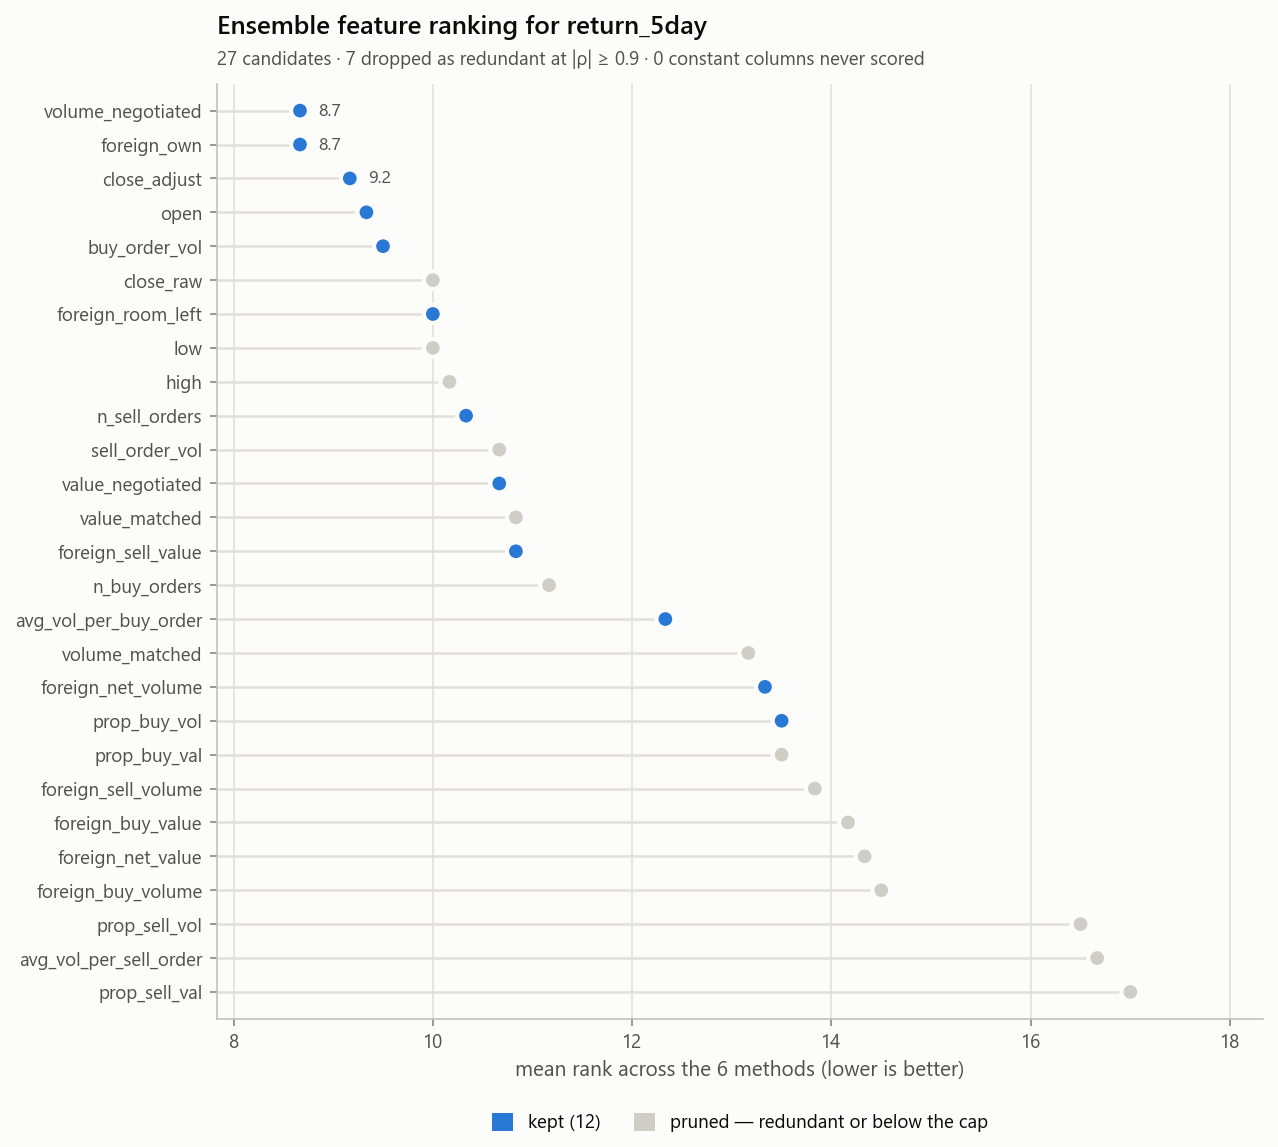

02_method_heatmap.png


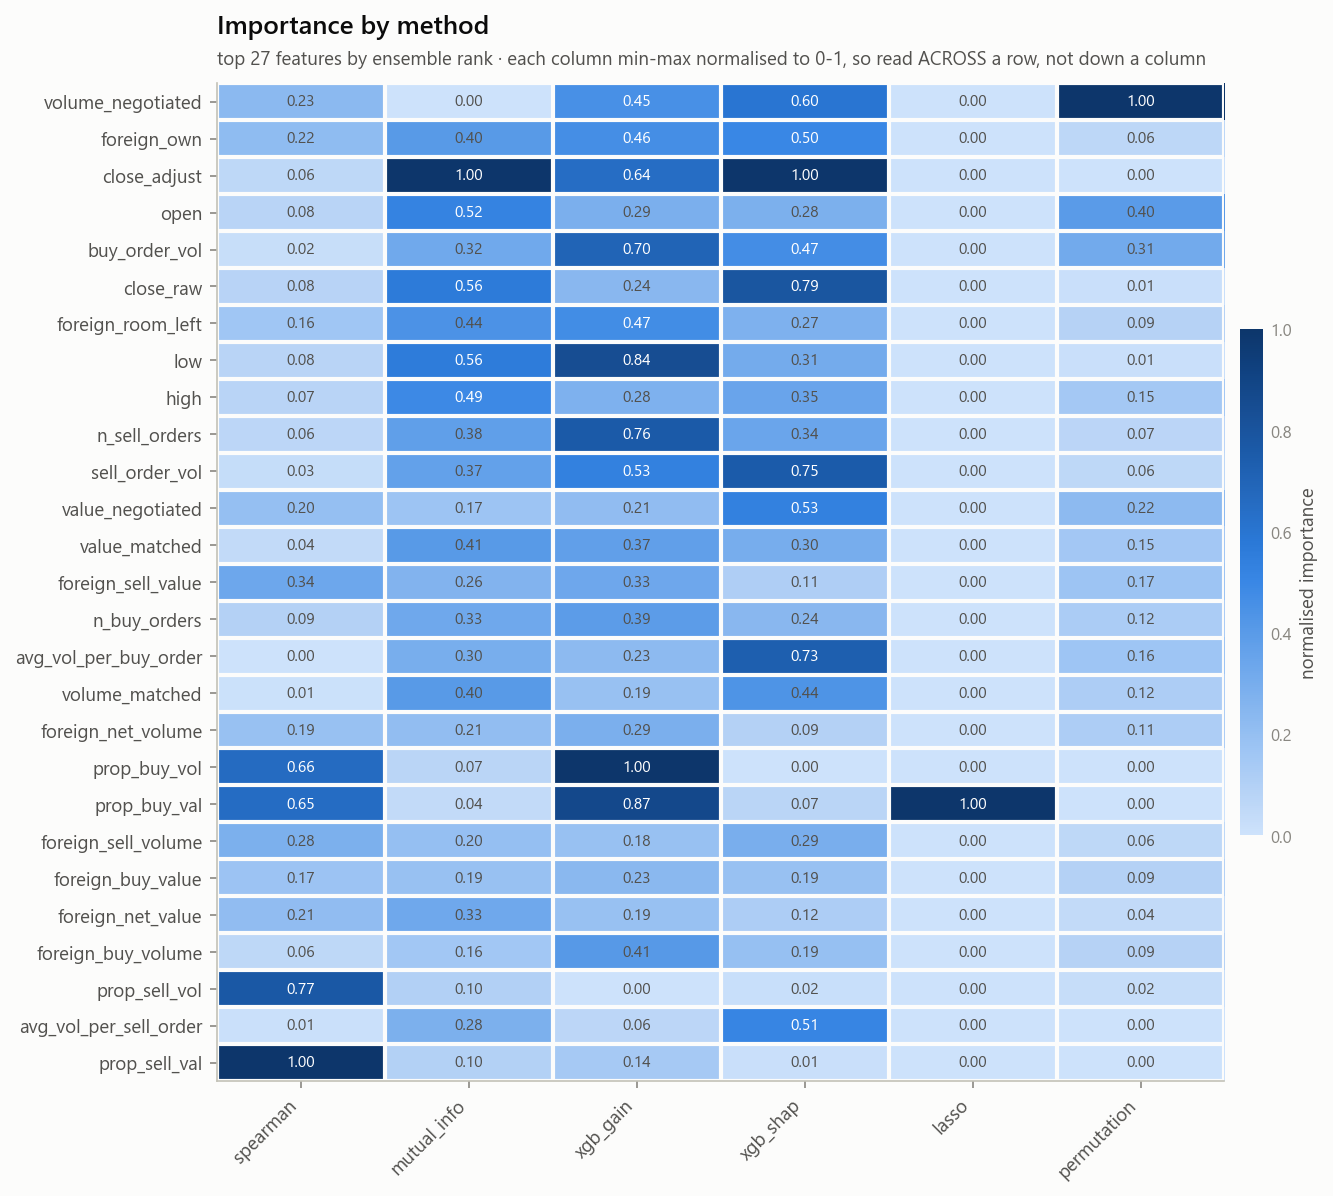

03_target_correlation.png


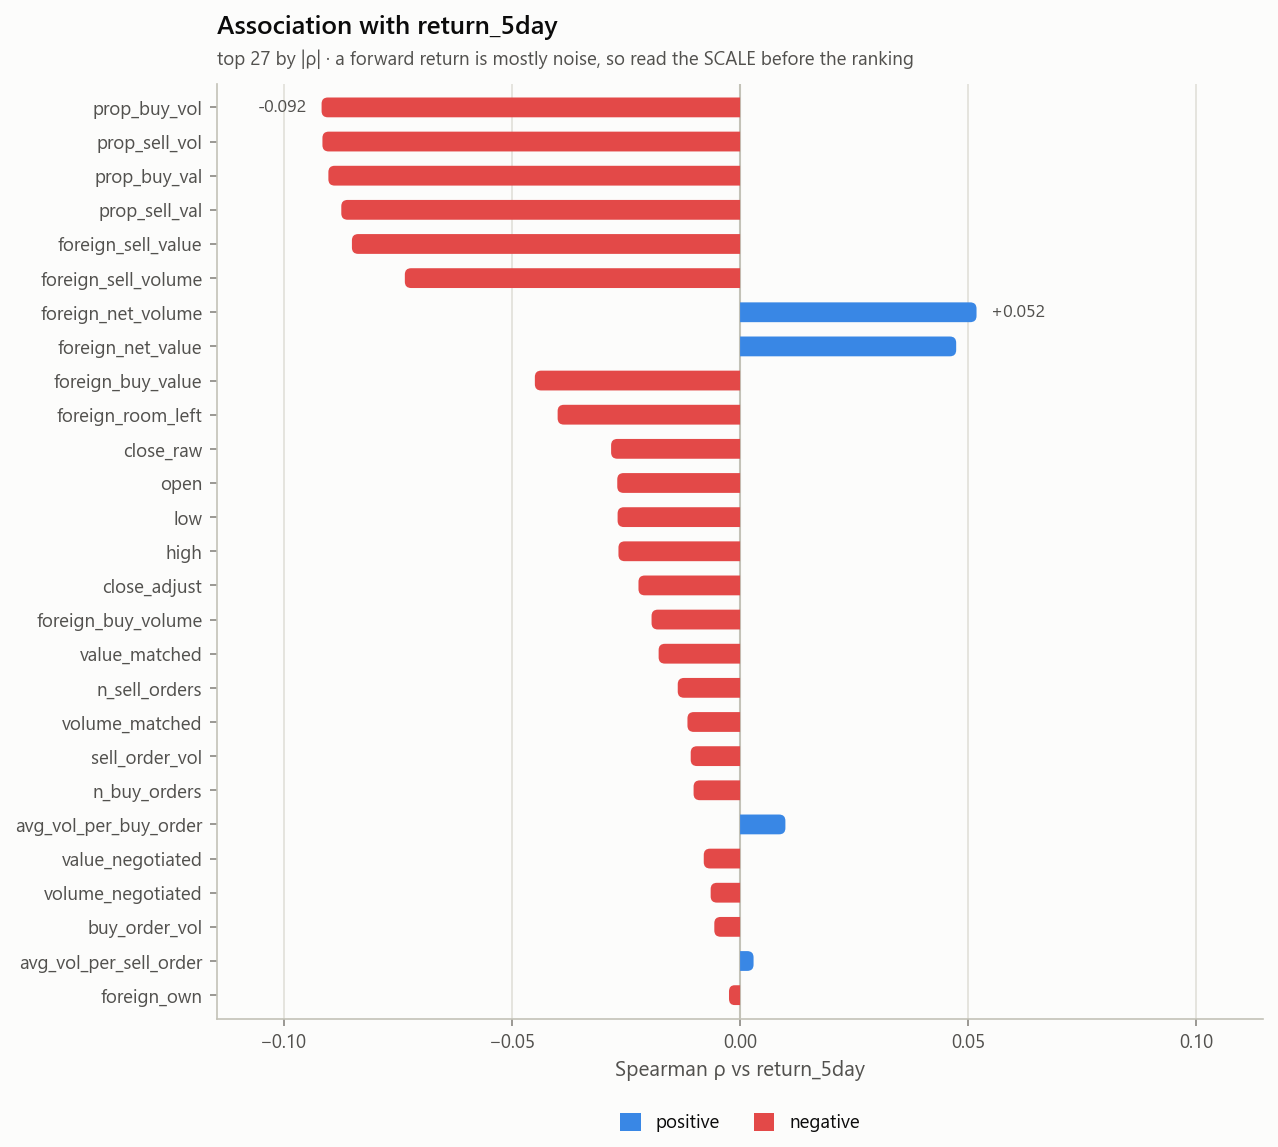

04_channel_correlation.png


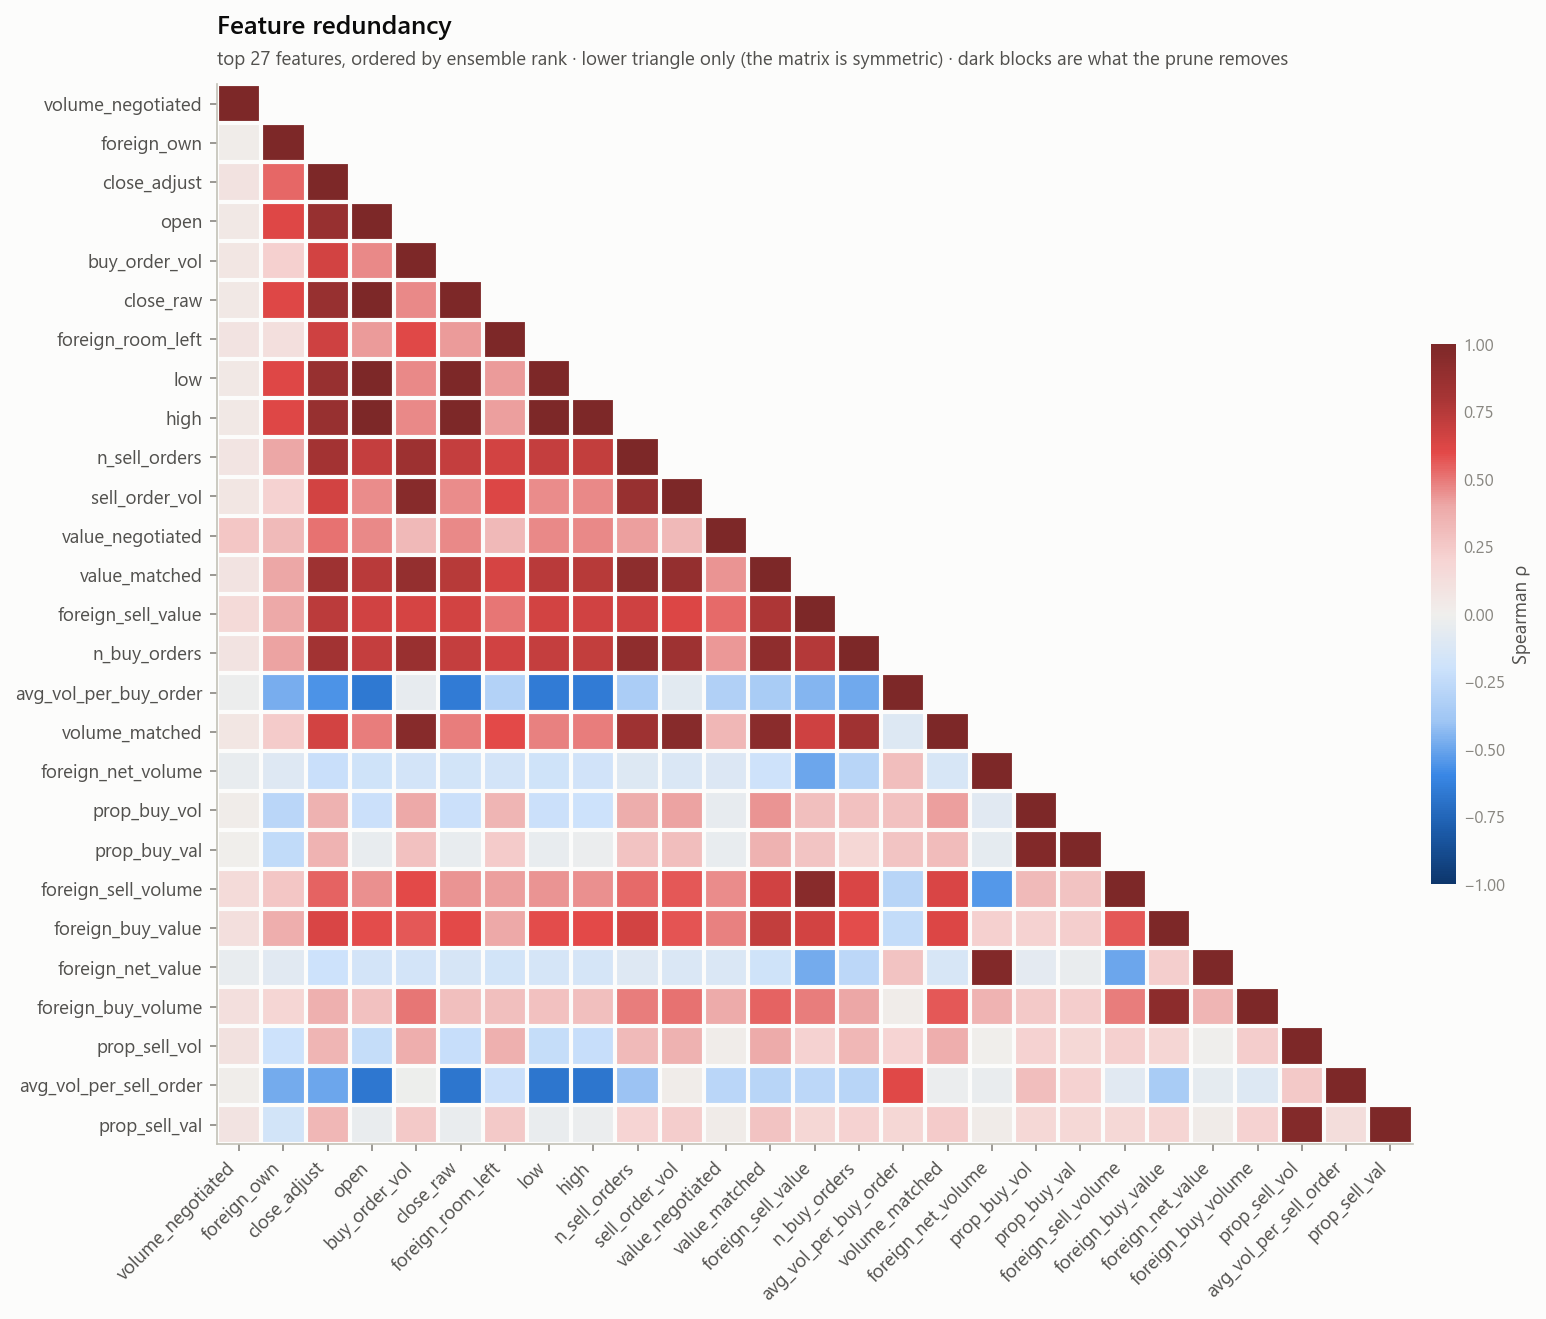

05_stat_profile.png


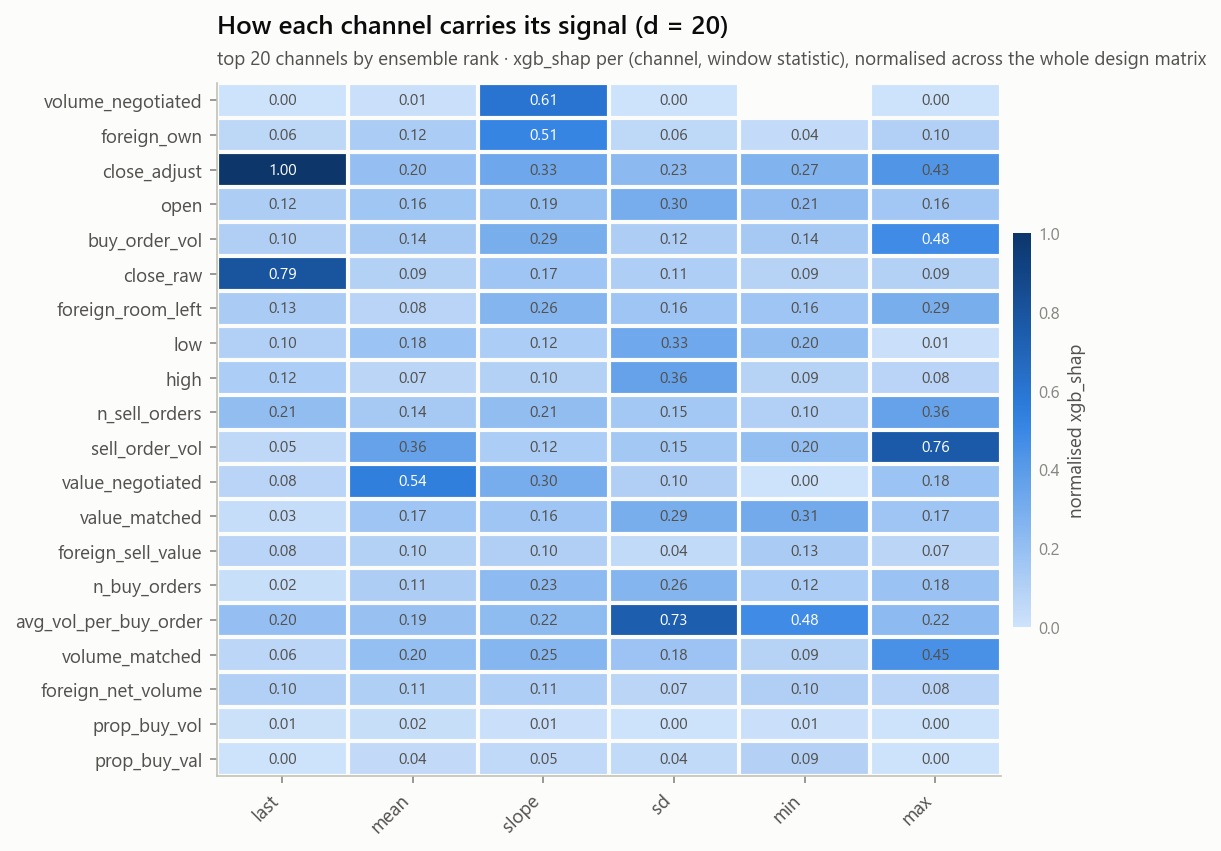

06_validation.png


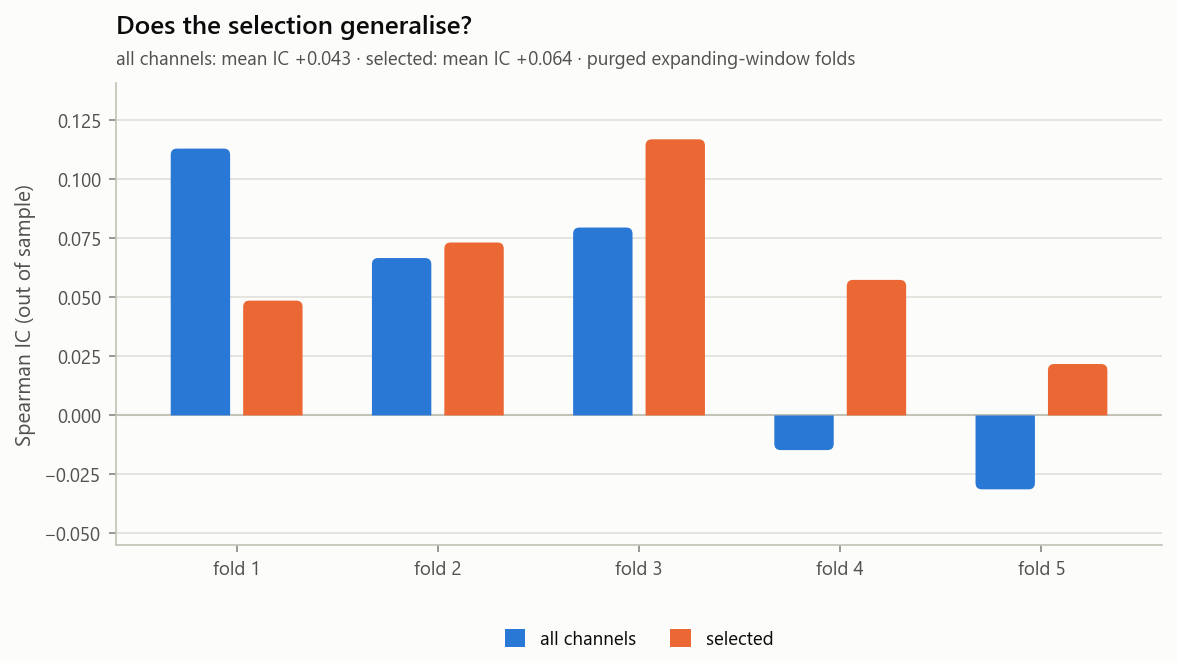

07_stability.png


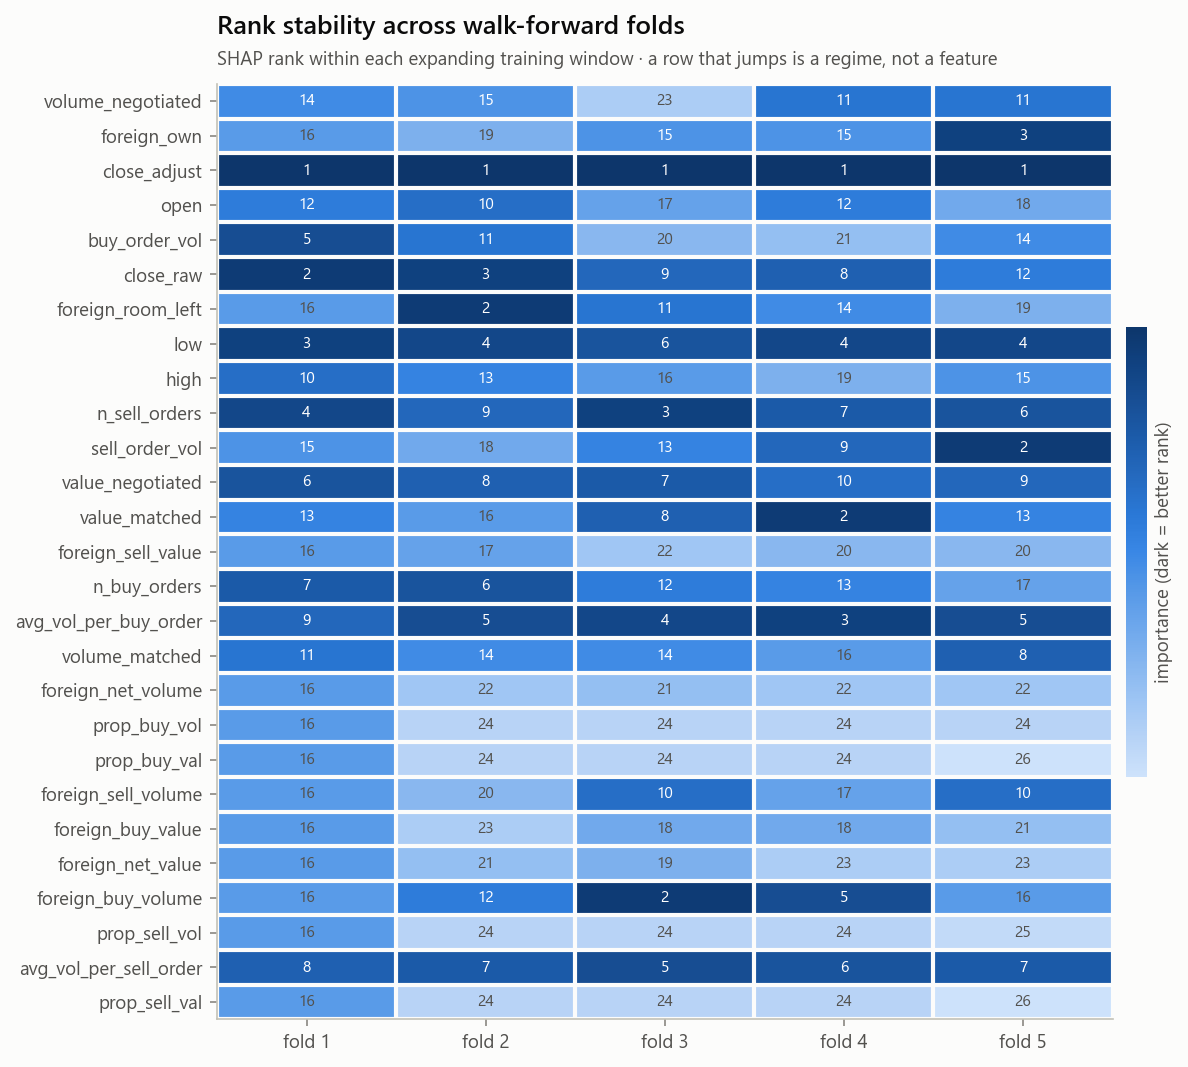

08_coverage.png


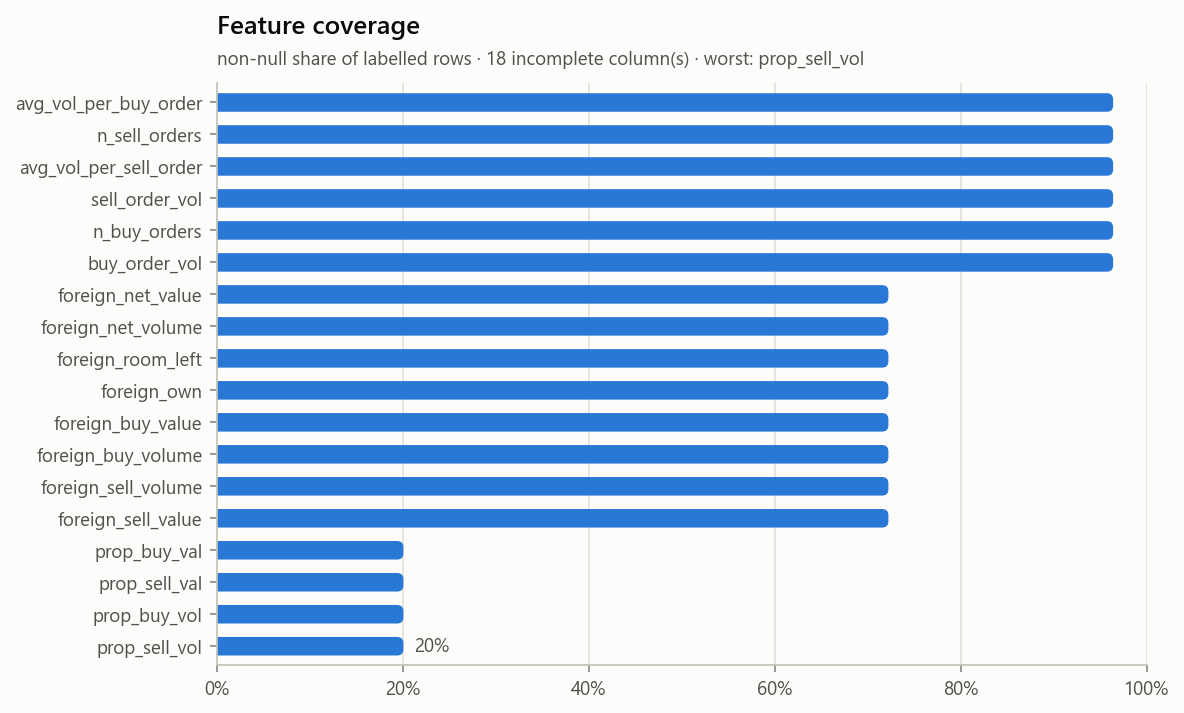

09_target_distribution.png


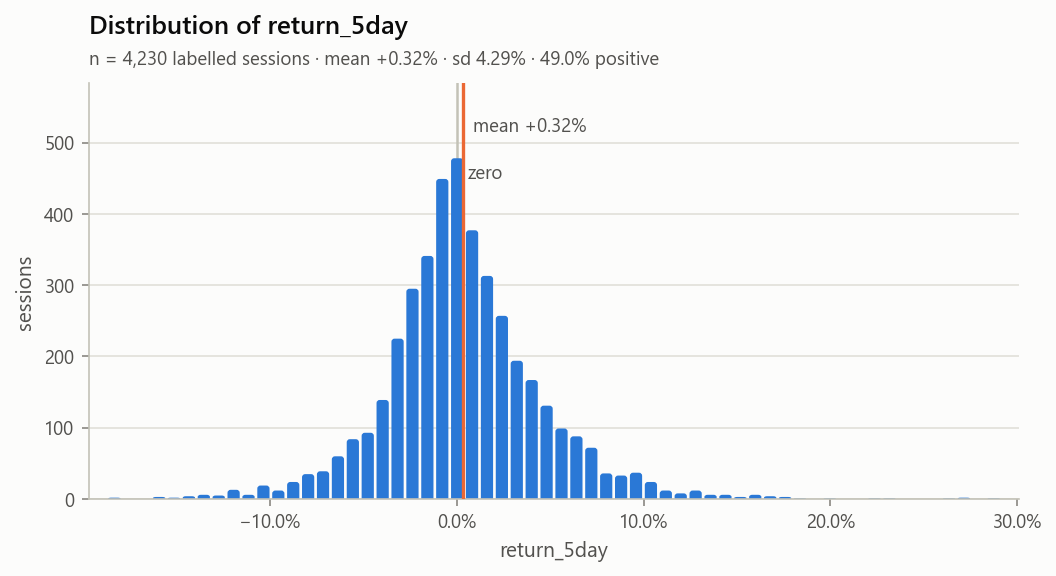

In [15]:
for figure in written.figures:
    print(os.path.basename(figure))
    display(Image(filename=figure, width=760))

### The feature-importance CSV, read back

In [16]:
pd.read_csv(written.importance_csv, index_col="channel").round(3)

,rank,ensemble,kept,dropped_for,spearman,mutual_info,xgb_gain,xgb_shap,lasso,permutation,spearman_vs_target,best_stat__spearman,best_stat__mutual_info,best_stat__xgb_gain,best_stat__xgb_shap,best_stat__lasso,best_stat__permutation
channel,,,,,,,,,,,,,,,,,
volume_negotiated,1,8.667,True,NaN,0.233,0.000,0.453,0.596,0.0,1.000,-0.006,slope,sd,slope,slope,last,slope
foreign_own,2,8.667,True,NaN,0.216,0.403,0.465,0.497,0.0,0.061,-0.002,slope,max,slope,slope,last,mean
close_adjust,3,9.167,True,NaN,0.055,1.000,0.645,1.000,0.0,0.000,-0.022,last,last,max,last,last,last
open,4,9.333,True,NaN,0.076,0.516,0.286,0.283,0.0,0.398,-0.027,last,max,min,sd,last,sd
buy_order_vol,5,9.500,True,NaN,0.022,0.323,0.701,0.468,0.0,0.313,-0.006,slope,max,min,max,last,slope
close_raw,6,10.000,False,open,0.082,0.563,0.241,0.787,0.0,0.014,-0.028,last,last,max,last,last,min
foreign_room_left,7,10.000,True,NaN,0.159,0.443,0.470,0.274,0.0,0.087,-0.040,slope,mean,min,max,last,sd
low,8,10.000,False,open,0.076,0.555,0.840,0.311,0.0,0.012,-0.027,last,last,min,sd,last,min
high,9,10.167,False,open,0.075,0.486,0.277,0.346,0.0,0.146,-0.027,last,last,max,sd,last,slope


## 5. Comparing runs

⚠️ **Built to make INCOMPARABILITY visible.** Two runs differing in `target`,
`normalize`, `lookback_d` or the universe are different experiments; their ICs must
not be set beside one another as if the difference were noise. `compare_reports`
puts those columns next to the IC so the difference is seen first.

In [17]:
root = report.DEFAULT_REPORT_ROOT
runs = [os.path.join(root, d) for d in sorted(os.listdir(root))
        if os.path.exists(os.path.join(root, d, "metadata.json"))]
report.compare_reports(runs)

,run_id,schema,target,rows,tickers,lookback_d,horizon_h,normalize,feature_normalize,device,kept,ic_mean,hit_rate,null_bar,z_vs_null,clears_null,commit
0,2026-08-04__unified_schema_vcb__return_5day__1...,unified_schema_vcb,return_5day,4235,1,20,5,none,None,cpu,12,0.063595,0.491974,None,None,None,a5082c8+dirty
1,2026-08-04__unified_schema_vcb__return_5day__2...,unified_schema_vcb,return_5day,4235,1,20,5,none,None,cpu,12,0.063595,0.491974,None,None,None,7ab2488+dirty
